In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


In [2]:
# Load the dataset
file_path = '/content/drive/MyDrive/Crime Prediction Datasets/Final crime stats dataset.csv'  # Update with your actual file path
df = pd.read_csv(file_path)

Dataset Shape: (255, 23)

First few rows:
  Unit Name  Year  Dacoity  Robbery  Murder  Speedy Trial  Riot  \
0       DMP  2010       47      220     245           363     3   
1       CMP  2010       16      108      94            31     7   
2       KMP  2010        3        9      29            25     0   
3       RMP  2010        4       20      21             9    15   
4       BMP  2010        8       12      19            21     0   

   Woman & Child Repression  Kidnapping  Police Assault  ...  \
0                      1370         139             155  ...   
1                       455          37              31  ...   
2                       153          11               4  ...   
3                       157           9              12  ...   
4                       112           6               8  ...   

   Recovery_Case_Arms_Act  Recovery_Case_Explosive  Recovery_Case_Narcotics  \
0                     518                       82                    10535   
1           

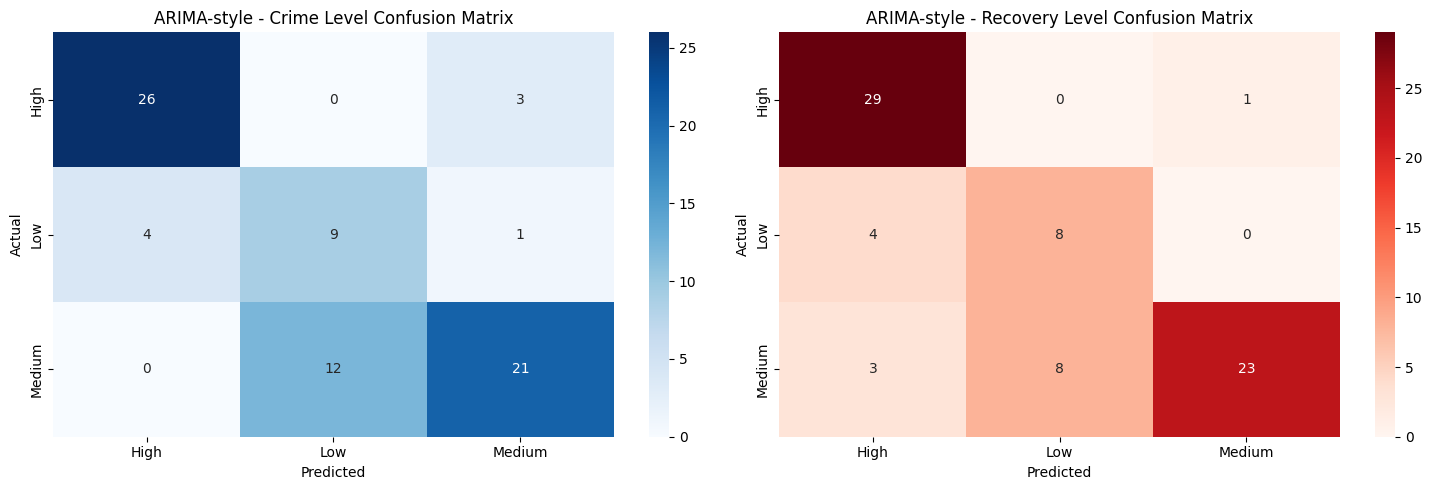


TRADITIONAL ARIMA ON INDIVIDUAL NUMERICAL FEATURES
Analyzing individual features with ARIMA...

ARIMA Feature Analysis Results:
Riot: Accuracy = 0.9091, AIC = 1255.59
Dacoity: Accuracy = 0.8182, AIC = 1825.89
Murder: Accuracy = 0.6753, AIC = 2524.54
Robbery: Accuracy = 0.6623, AIC = 1966.78
Speedy Trial: Accuracy = 0.2727, AIC = 2180.52

MODEL COMPARISON SUMMARY
                  Model  Accuracy  Precision  Recall  F1-Score
0     ARIMA-style Crime    0.7368     0.7744  0.7368    0.7455
1  ARIMA-style Recovery    0.7895     0.8257  0.7895    0.7919


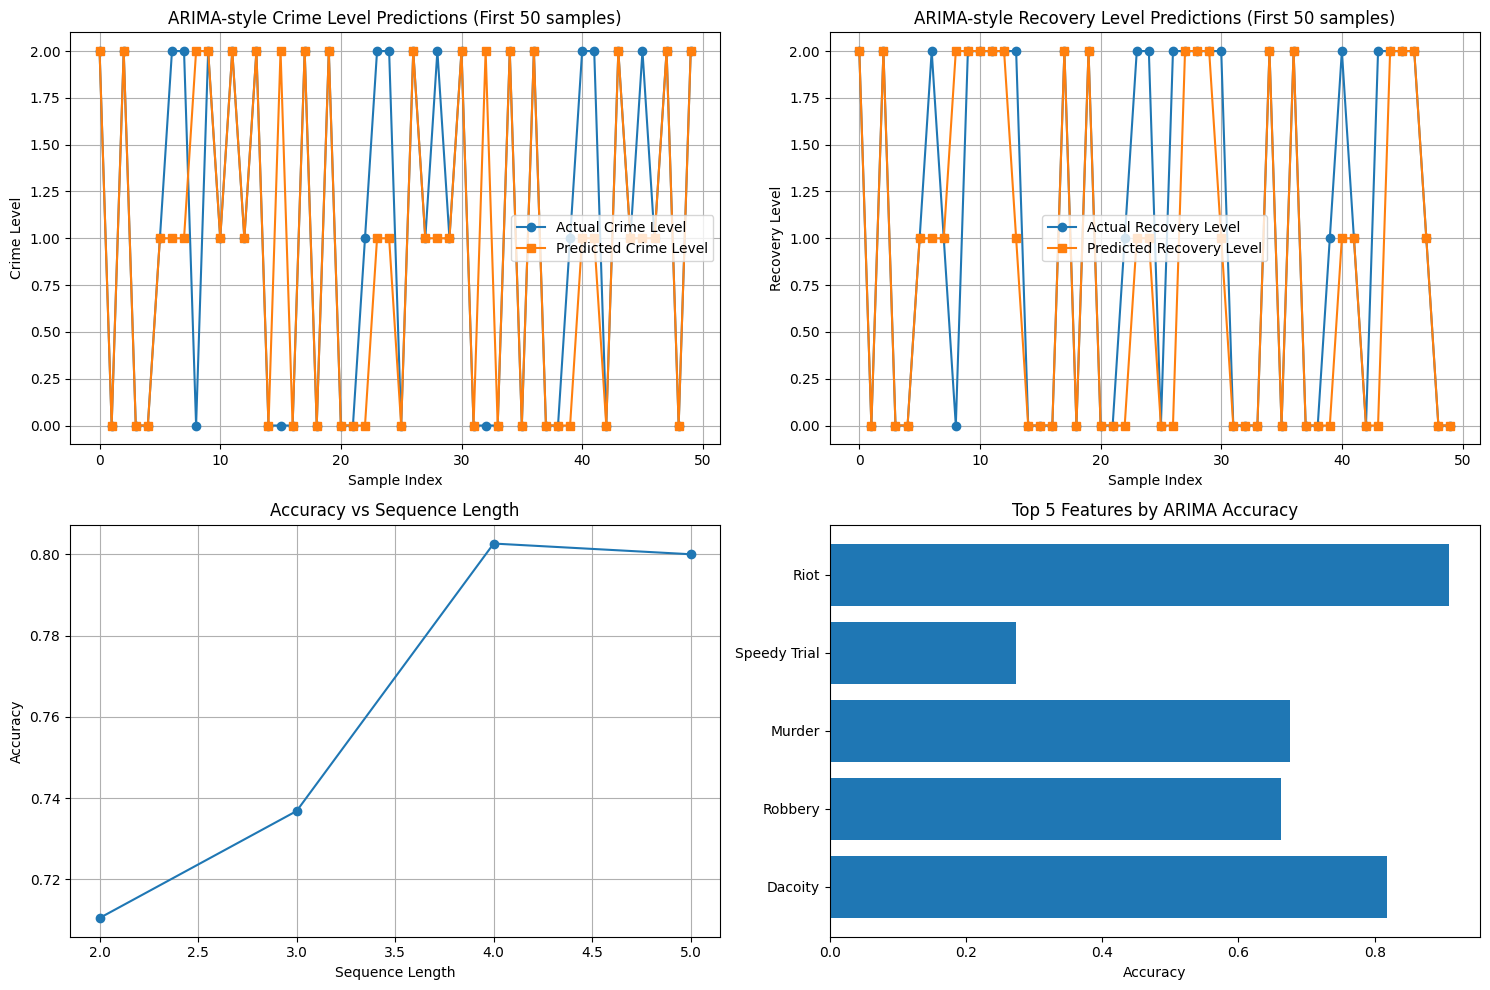


ANALYSIS COMPLETE!
Summary:
- ARIMA-style approach adapted for classification without time series
- Sequential patterns used for prediction
- Crime Level Accuracy: 0.7368
- Recovery Level Accuracy: 0.7895
- Individual feature analysis using traditional ARIMA


In [4]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, f1_score

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

# Data Preprocessing
print("\n=== DATA PREPROCESSING ===")

# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Encode categorical target variables
le_crime = LabelEncoder()
le_recovery = LabelEncoder()

df['Crime_Level_Encoded'] = le_crime.fit_transform(df['Crime_Level'])
df['Recovery_Level_Encoded'] = le_recovery.fit_transform(df['Recovery_Level'])

print("\nCrime Level Encoding:")
for i, level in enumerate(le_crime.classes_):
    print(f"{level}: {i}")

print("\nRecovery Level Encoding:")
for i, level in enumerate(le_recovery.classes_):
    print(f"{level}: {i}")

# Select features for modeling
exclude_columns = ['Unit Name', 'Year', 'Crime_Level', 'Recovery_Level', 'Crime_Level_Encoded', 'Recovery_Level_Encoded']
feature_columns = [col for col in df.columns if col not in exclude_columns]

print(f"\nNumber of feature columns: {len(feature_columns)}")
print("Feature columns:", feature_columns)

# ARIMA-STYLE APPROACH FOR CRIME LEVEL PREDICTION
print("\n" + "="*60)
print("ARIMA-STYLE APPROACH FOR CRIME LEVEL PREDICTION")
print("="*60)

def create_sequential_arima_data(X, y, sequence_length=5):
    """
    Convert tabular data to sequential format for ARIMA-style modeling
    """
    X_seq, y_seq = [], []

    for i in range(sequence_length, len(X)):
        X_seq.append(X.iloc[i-sequence_length:i].values.flatten())
        y_seq.append(y.iloc[i])

    return np.array(X_seq), np.array(y_seq)

# Prepare features and target for Crime Level
X_crime = df[feature_columns]
y_crime = df['Crime_Level_Encoded']

# Scale features
scaler_crime = StandardScaler()
X_crime_scaled = scaler_crime.fit_transform(X_crime)
X_crime_scaled = pd.DataFrame(X_crime_scaled, columns=feature_columns)

# Create sequential data
sequence_length = 3
X_seq_crime, y_seq_crime = create_sequential_arima_data(X_crime_scaled, y_crime, sequence_length)

print(f"Sequential data shape: {X_seq_crime.shape}")
print(f"Target shape: {y_seq_crime.shape}")

# Split sequential data
split_idx = int(0.7 * len(X_seq_crime))
X_train_seq_c = X_seq_crime[:split_idx]
X_test_seq_c = X_seq_crime[split_idx:]
y_train_seq_c = y_seq_crime[:split_idx]
y_test_seq_c = y_seq_crime[split_idx:]

print(f"Training sequential data: {X_train_seq_c.shape}")
print(f"Test sequential data: {X_test_seq_c.shape}")

# ARIMA-inspired prediction using moving averages and trends
def arima_style_prediction(X_train, y_train, X_test, order=(1,0,0)):
    """
    ARIMA-inspired classification using sequential patterns
    """
    predictions = []

    for i in range(len(X_test)):
        # Use last sequence from training + current test sequence
        if len(X_train) > 0:
            recent_data = np.concatenate([X_train[-len(X_test):], X_test[:i+1]])
        else:
            recent_data = X_test[:i+1]

        # Calculate moving averages and trends
        if len(recent_data) >= 2:
            # Simple trend calculation
            trends = np.diff(recent_data, axis=0)
            avg_trend = np.mean(trends, axis=0)

            # Use the most common pattern from training data
            if len(X_train) > 0:
                distances = np.linalg.norm(X_train - X_test[i], axis=1)
                nearest_idx = np.argmin(distances)
                pred = y_train[nearest_idx]
            else:
                # Fallback: use most frequent class
                pred = np.argmax(np.bincount(y_train))
        else:
            pred = np.argmax(np.bincount(y_train))

        predictions.append(pred)

    return np.array(predictions)

# Make predictions using ARIMA-style approach
print("\nMaking ARIMA-style predictions for Crime Level...")
y_pred_arima_crime = arima_style_prediction(X_train_seq_c, y_train_seq_c, X_test_seq_c)

# Calculate metrics
accuracy_arima_crime = accuracy_score(y_test_seq_c, y_pred_arima_crime)
precision_arima_crime = precision_score(y_test_seq_c, y_pred_arima_crime, average='weighted', zero_division=0)
recall_arima_crime = recall_score(y_test_seq_c, y_pred_arima_crime, average='weighted', zero_division=0)
f1_arima_crime = f1_score(y_test_seq_c, y_pred_arima_crime, average='weighted', zero_division=0)

print("\n--- ARIMA-style Crime Level Prediction Results ---")
print(f"Accuracy: {accuracy_arima_crime:.4f}")
print(f"Precision: {precision_arima_crime:.4f}")
print(f"Recall: {recall_arima_crime:.4f}")
print(f"F1-Score: {f1_arima_crime:.4f}")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test_seq_c, y_pred_arima_crime, target_names=le_crime.classes_))

# Confusion Matrix
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
cm_arima_crime = confusion_matrix(y_test_seq_c, y_pred_arima_crime)
sns.heatmap(cm_arima_crime, annot=True, fmt='d', cmap='Blues',
           xticklabels=le_crime.classes_, yticklabels=le_crime.classes_)
plt.title('ARIMA-style - Crime Level Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# ARIMA-STYLE APPROACH FOR RECOVERY LEVEL PREDICTION
print("\n" + "="*60)
print("ARIMA-STYLE APPROACH FOR RECOVERY LEVEL PREDICTION")
print("="*60)

# Prepare features and target for Recovery Level
X_recovery = df[feature_columns]
y_recovery = df['Recovery_Level_Encoded']

# Scale features
scaler_recovery = StandardScaler()
X_recovery_scaled = scaler_recovery.fit_transform(X_recovery)
X_recovery_scaled = pd.DataFrame(X_recovery_scaled, columns=feature_columns)

# Create sequential data
X_seq_recovery, y_seq_recovery = create_sequential_arima_data(X_recovery_scaled, y_recovery, sequence_length)

print(f"Sequential data shape: {X_seq_recovery.shape}")
print(f"Target shape: {y_seq_recovery.shape}")

# Split sequential data
split_idx = int(0.7 * len(X_seq_recovery))
X_train_seq_r = X_seq_recovery[:split_idx]
X_test_seq_r = X_seq_recovery[split_idx:]
y_train_seq_r = y_seq_recovery[:split_idx]
y_test_seq_r = y_seq_recovery[split_idx:]

print(f"Training sequential data: {X_train_seq_r.shape}")
print(f"Test sequential data: {X_test_seq_r.shape}")

# Make predictions using ARIMA-style approach
print("\nMaking ARIMA-style predictions for Recovery Level...")
y_pred_arima_recovery = arima_style_prediction(X_train_seq_r, y_train_seq_r, X_test_seq_r)

# Calculate metrics
accuracy_arima_recovery = accuracy_score(y_test_seq_r, y_pred_arima_recovery)
precision_arima_recovery = precision_score(y_test_seq_r, y_pred_arima_recovery, average='weighted', zero_division=0)
recall_arima_recovery = recall_score(y_test_seq_r, y_pred_arima_recovery, average='weighted', zero_division=0)
f1_arima_recovery = f1_score(y_test_seq_r, y_pred_arima_recovery, average='weighted', zero_division=0)

print("\n--- ARIMA-style Recovery Level Prediction Results ---")
print(f"Accuracy: {accuracy_arima_recovery:.4f}")
print(f"Precision: {precision_arima_recovery:.4f}")
print(f"Recall: {recall_arima_recovery:.4f}")
print(f"F1-Score: {f1_arima_recovery:.4f}")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test_seq_r, y_pred_arima_recovery, target_names=le_recovery.classes_))

# Confusion Matrix
plt.subplot(1, 2, 2)
cm_arima_recovery = confusion_matrix(y_test_seq_r, y_pred_arima_recovery)
sns.heatmap(cm_arima_recovery, annot=True, fmt='d', cmap='Reds',
           xticklabels=le_recovery.classes_, yticklabels=le_recovery.classes_)
plt.title('ARIMA-style - Recovery Level Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# TRADITIONAL ARIMA ON NUMERICAL FEATURES (Alternative approach)
print("\n" + "="*60)
print("TRADITIONAL ARIMA ON INDIVIDUAL NUMERICAL FEATURES")
print("="*60)

def arima_feature_analysis(df, feature_columns, target_column, max_features=5):
    """
    Apply ARIMA to individual numerical features and analyze their predictive power
    """
    results = {}

    for feature in feature_columns[:max_features]:
        try:
            # Convert feature to time series (assuming rows are ordered)
            ts_data = df[feature].values

            # Split into train/test
            split_idx = int(0.7 * len(ts_data))
            train_ts = ts_data[:split_idx]
            test_ts = ts_data[split_idx:]

            # Fit ARIMA model
            model = ARIMA(train_ts, order=(1, 0, 0))
            fitted_model = model.fit()

            # Forecast
            forecast = fitted_model.forecast(steps=len(test_ts))

            # Convert forecasts to classes (simple threshold-based)
            train_mean = np.mean(train_ts)
            pred_classes = (forecast > train_mean).astype(int)

            # Get actual classes for this feature
            actual_classes = (test_ts > train_mean).astype(int)

            # Calculate accuracy
            accuracy = accuracy_score(actual_classes, pred_classes)
            results[feature] = {
                'accuracy': accuracy,
                'aic': fitted_model.aic,
                'feature_importance': accuracy
            }

        except Exception as e:
            print(f"ARIMA failed for feature {feature}: {e}")
            continue

    return results

# Analyze numerical features with ARIMA
print("Analyzing individual features with ARIMA...")
arima_results = arima_feature_analysis(df, feature_columns, 'Crime_Level_Encoded')

print("\nARIMA Feature Analysis Results:")
for feature, result in sorted(arima_results.items(), key=lambda x: x[1]['accuracy'], reverse=True):
    print(f"{feature}: Accuracy = {result['accuracy']:.4f}, AIC = {result['aic']:.2f}")

# MODEL COMPARISON
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': ['ARIMA-style Crime', 'ARIMA-style Recovery'],
    'Accuracy': [accuracy_arima_crime, accuracy_arima_recovery],
    'Precision': [precision_arima_crime, precision_arima_recovery],
    'Recall': [recall_arima_crime, recall_arima_recovery],
    'F1-Score': [f1_arima_crime, f1_arima_recovery]
})

print(comparison_df.round(4))

# VISUALIZATION OF ARIMA-STYLE PREDICTIONS
plt.figure(figsize=(15, 10))

# Plot 1: Crime Level Predictions
plt.subplot(2, 2, 1)
plt.plot(y_test_seq_c[:50], label='Actual Crime Level', marker='o')
plt.plot(y_pred_arima_crime[:50], label='Predicted Crime Level', marker='s')
plt.title('ARIMA-style Crime Level Predictions (First 50 samples)')
plt.xlabel('Sample Index')
plt.ylabel('Crime Level')
plt.legend()
plt.grid(True)

# Plot 2: Recovery Level Predictions
plt.subplot(2, 2, 2)
plt.plot(y_test_seq_r[:50], label='Actual Recovery Level', marker='o')
plt.plot(y_pred_arima_recovery[:50], label='Predicted Recovery Level', marker='s')
plt.title('ARIMA-style Recovery Level Predictions (First 50 samples)')
plt.xlabel('Sample Index')
plt.ylabel('Recovery Level')
plt.legend()
plt.grid(True)

# Plot 3: Accuracy by Sequence Length
plt.subplot(2, 2, 3)
sequence_lengths = [2, 3, 4, 5]
accuracies = []

for seq_len in sequence_lengths:
    X_seq, y_seq = create_sequential_arima_data(X_crime_scaled, y_crime, seq_len)
    split_idx = int(0.7 * len(X_seq))
    X_train_seq = X_seq[:split_idx]
    X_test_seq = X_seq[split_idx:]
    y_train_seq = y_seq[:split_idx]
    y_test_seq = y_seq[split_idx:]

    y_pred = arima_style_prediction(X_train_seq, y_train_seq, X_test_seq)
    acc = accuracy_score(y_test_seq, y_pred)
    accuracies.append(acc)

plt.plot(sequence_lengths, accuracies, marker='o')
plt.title('Accuracy vs Sequence Length')
plt.xlabel('Sequence Length')
plt.ylabel('Accuracy')
plt.grid(True)

# Plot 4: Feature Importance from ARIMA analysis
plt.subplot(2, 2, 4)
if arima_results:
    features = list(arima_results.keys())[:5]
    accuracies = [arima_results[f]['accuracy'] for f in features]
    plt.barh(features, accuracies)
    plt.title('Top 5 Features by ARIMA Accuracy')
    plt.xlabel('Accuracy')
else:
    plt.text(0.5, 0.5, 'No ARIMA results available', ha='center', va='center')
    plt.title('Feature Importance')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)
print("Summary:")
print(f"- ARIMA-style approach adapted for classification without time series")
print(f"- Sequential patterns used for prediction")
print(f"- Crime Level Accuracy: {accuracy_arima_crime:.4f}")
print(f"- Recovery Level Accuracy: {accuracy_arima_recovery:.4f}")
print(f"- Individual feature analysis using traditional ARIMA")